# 04b – Könnyű CNN-ek (MobileNetV3 & ShuffleNetV2)

**Szerző:** Magda Ferenc (U5O0BB)  
**Projekt:** Gitár-akkord felismerő szoftver gépi látással  
**Notebook célja:** Könnyűsúlyú CNN architektúrák fine-tuningja és összehasonlítása.

**Modellek:**
1. MobileNetV3-Small  
2. MobileNetV3-Large  
3. ShuffleNetV2 (x1.0)

**Miért ezek először?**
Kis adathalmazon a mobilarchitektúrák gyorsabbak, kevesebb VRAM kell,
és meglepően versenyképesek. Referenciapont az EfficientNet előtt.

---

## Notebook sorozat

| Notebook | Modell | Státusz |
|----------|--------|---------|
| `04a` | Hagyományos ML (SVM, RF, XGBoost) | előző |
| **`04b`** | **MobileNetV3, ShuffleNetV2** | **← jelen** |
| `04c` | EfficientNet-B0 | következő |
| `04d` | ResNet-50, EfficientNet-B3 | tervezett |
| `04e` | ViT-B/16 (opcionális) | tervezett |

---

## Tartalomjegyzék
1. Konfiguráció  
2. DataLoader  
3. Modell builder és trainer  
4. MobileNetV3-Small  
5. MobileNetV3-Large  
6. ShuffleNetV2 (x1.0)  
7. Összehasonlítás  
8. Összefoglaló


## 1. Konfiguráció

In [1]:
import warnings, time, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torchvision.models as tv_models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, f1_score)

warnings.filterwarnings("ignore")

NOTEBOOK_DIR   = Path.cwd()
PROJECT_ROOT   = NOTEBOOK_DIR.parent
DATA_ROOT      = PROJECT_ROOT / "data"
MANIFEST_PATH  = DATA_ROOT / "split_manifest.csv"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
OUTPUT_DIR     = PROJECT_ROOT / "output" / "04b_mobile_cnn"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE    = 224
BATCH_SIZE  = 16
NUM_WORKERS = 0
RANDOM_SEED = 42
LR_A, EPOCHS_A, PATIENCE_A = 1e-3, 20, 8
LR_B_HEAD, LR_B_BB         = 1e-4, 1e-5
EPOCHS_B, PATIENCE_B        = 25, 10
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
print(f"Eszkoz: {DEVICE}")


Eszkoz: cuda


## 2. DataLoader

In [2]:
manifest = pd.read_csv(MANIFEST_PATH)
CLASSES     = sorted(manifest["class"].unique())
CLASS2IDX   = {c: i for i, c in enumerate(CLASSES)}
IDX2CLASS   = {i: c for c, i in CLASS2IDX.items()}
NUM_CLASSES = len(CLASSES)
manifest["label"] = manifest["class"].map(CLASS2IDX)

train_df = manifest[manifest["split"] == "train"].reset_index(drop=True)
val_df   = manifest[manifest["split"] == "val"].reset_index(drop=True)
test_df  = manifest[manifest["split"] == "test"].reset_index(drop=True)

class_counts  = train_df["class"].value_counts()
class_weights = torch.tensor(
    [len(train_df) / (NUM_CLASSES * class_counts.get(c, 1)) for c in CLASSES],
    dtype=torch.float
).to(DEVICE)

train_tf = T.Compose([T.Resize(256), T.RandomCrop(IMG_SIZE),
                       T.RandomHorizontalFlip(0.5),
                       T.ColorJitter(0.3, 0.3, 0.2, 0.1), T.RandomRotation(15),
                       T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
valtest_tf = T.Compose([T.Resize(256), T.CenterCrop(IMG_SIZE),
                         T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

class GuitarChordDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df, self.transform = df.reset_index(drop=True), transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, int(row["label"])

train_loader = DataLoader(GuitarChordDataset(train_df, train_tf),
    BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(GuitarChordDataset(val_df,   valtest_tf),
    BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(GuitarChordDataset(test_df,  valtest_tf),
    BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
print(f"Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)}")


Train 207 | Val 45 | Test 45


## 3. Modell builder és trainer segédletek

In [3]:
# ── Újrafelhasználható training segédletek ─────────────────────────────────────

class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4, ckpt_path=None):
        self.patience, self.min_delta = patience, min_delta
        self.ckpt_path = ckpt_path
        self.best_loss, self.counter, self.best_state = float("inf"), 0, None
    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss; self.counter = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if self.ckpt_path: torch.save(self.best_state, self.ckpt_path)
        else: self.counter += 1
        return self.counter >= self.patience
    def restore_best(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)
            print(f"  Best model restored (val_loss={self.best_loss:.4f})")

def run_epoch(model, loader, criterion, optimizer=None, phase="train"):
    is_train = phase == "train"
    model.train() if is_train else model.eval()
    total_loss = correct = total = 0
    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs); loss = criterion(logits, labels)
            if is_train: optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()*len(labels)
            correct    += (logits.argmax(1)==labels).sum().item()
            total      += len(labels)
    return total_loss/total, correct/total

def train_model(model, label=""):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optA = AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                 lr=LR_A, weight_decay=1e-4)
    schA = CosineAnnealingLR(optA, T_max=EPOCHS_A, eta_min=1e-5)
    esA  = EarlyStopping(patience=PATIENCE_A,
                          ckpt_path=CHECKPOINT_DIR/f"best_{label}_phA.pth")
    hist_a = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
    t0 = time.time()
    print(f"[{label}] Fazis A – frozen backbone")
    for ep in range(1, EPOCHS_A+1):
        tl, ta = run_epoch(model, train_loader, criterion, optA, "train")
        vl, va = run_epoch(model, val_loader,   criterion, None, "val")
        schA.step()
        for k, v in zip(hist_a, [tl, vl, ta, va]): hist_a[k].append(v)
        print(f"  Ep {ep:>2}  tr_loss={tl:.4f}  tr_acc={ta:.3f}  vl_loss={vl:.4f}  vl_acc={va:.3f}  ({time.time()-t0:.0f}s)")
        if esA.step(vl, model): print("  Early stop."); break
    esA.restore_best(model)

    # Fazis B – unfreeze last 3 blocks
    blocks = list(model.features.children()) if hasattr(model, "features") else []
    for blk in blocks[-3:]:
        for p in blk.parameters(): p.requires_grad = True
    optB = AdamW([
        {"params": model.features.parameters() if hasattr(model,"features") else [], "lr": LR_B_BB},
        {"params": model.classifier.parameters() if hasattr(model,"classifier") else
                   list(model.fc.parameters() if hasattr(model,"fc") else []), "lr": LR_B_HEAD},
    ], weight_decay=1e-4)
    schB = CosineAnnealingLR(optB, T_max=EPOCHS_B, eta_min=1e-6)
    esB  = EarlyStopping(patience=PATIENCE_B,
                          ckpt_path=CHECKPOINT_DIR/f"best_{label}_phB.pth")
    hist_b = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
    print(f"[{label}] Fazis B – partial unfreeze")
    for ep in range(1, EPOCHS_B+1):
        tl, ta = run_epoch(model, train_loader, criterion, optB, "train")
        vl, va = run_epoch(model, val_loader,   criterion, None, "val")
        schB.step()
        for k, v in zip(hist_b, [tl, vl, ta, va]): hist_b[k].append(v)
        print(f"  Ep {ep:>2}  tr_loss={tl:.4f}  tr_acc={ta:.3f}  vl_loss={vl:.4f}  vl_acc={va:.3f}  ({time.time()-t0:.0f}s)")
        if esB.step(vl, model): print("  Early stop."); break
    esB.restore_best(model)
    return hist_a, hist_b

def evaluate_model(model, label=""):
    model.eval(); preds, labels_all = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            p = model(imgs.to(DEVICE)).argmax(1).cpu().tolist()
            preds.extend(p); labels_all.extend(labels.tolist())
    acc = accuracy_score(labels_all, preds)
    f1  = f1_score(labels_all, preds, average="macro")
    print(f"[{label}] Test acc={acc:.4f}  macro-F1={f1:.4f}")
    print(classification_report(labels_all, preds, target_names=CLASSES, digits=3))
    return acc, f1, preds, labels_all

ALL_RESULTS = []
print("Utils betoltve.")


Utils betoltve.


## 4. MobileNetV3-Small

~2.5M paraméter, gyors inference, ideális mobil deploymenthez.

In [4]:
# MobileNetV3-Small
mob_small = tv_models.mobilenet_v3_small(weights=tv_models.MobileNet_V3_Small_Weights.DEFAULT)
for p in mob_small.features.parameters(): p.requires_grad = False
mob_small.classifier[-1] = nn.Linear(mob_small.classifier[-1].in_features, NUM_CLASSES)
mob_small = mob_small.to(DEVICE)

total = sum(p.numel() for p in mob_small.parameters())
trainable = sum(p.numel() for p in mob_small.parameters() if p.requires_grad)
print(f"MobileNetV3-Small  teljes={total:,}  tanithato={trainable:,} ({100*trainable/total:.1f}%)")

hist_a_ms, hist_b_ms = train_model(mob_small, label="MobSmall")
acc_ms, f1_ms, preds_ms, labels_ms = evaluate_model(mob_small, "MobSmall")
ALL_RESULTS.append({"Model": "MobileNetV3-Small", "Test Acc": acc_ms, "Macro F1": f1_ms})
torch.save(mob_small.state_dict(), CHECKPOINT_DIR / "mobilenet_v3_small.pth")


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /home/feri/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth
100%|██████████| 9.83M/9.83M [00:00<00:00, 27.3MB/s]


MobileNetV3-Small  teljes=1,526,056  tanithato=599,048 (39.3%)
[MobSmall] Fazis A – frozen backbone
  Ep  1  tr_loss=2.0448  tr_acc=0.266  vl_loss=1.9787  vl_acc=0.200  (44s)
  Ep  2  tr_loss=1.6506  tr_acc=0.323  vl_loss=1.6740  vl_acc=0.222  (87s)
  Ep  3  tr_loss=1.3091  tr_acc=0.562  vl_loss=1.6386  vl_acc=0.311  (131s)
  Ep  4  tr_loss=1.0812  tr_acc=0.604  vl_loss=1.4067  vl_acc=0.489  (176s)
  Ep  5  tr_loss=1.0252  tr_acc=0.625  vl_loss=1.2539  vl_acc=0.556  (220s)
  Ep  6  tr_loss=0.9583  tr_acc=0.661  vl_loss=1.6619  vl_acc=0.333  (262s)
  Ep  7  tr_loss=1.0002  tr_acc=0.641  vl_loss=1.0158  vl_acc=0.622  (305s)
  Ep  8  tr_loss=0.8764  tr_acc=0.667  vl_loss=1.1436  vl_acc=0.511  (347s)
  Ep  9  tr_loss=0.7760  tr_acc=0.703  vl_loss=0.8816  vl_acc=0.600  (389s)
  Ep 10  tr_loss=0.7015  tr_acc=0.755  vl_loss=0.7939  vl_acc=0.689  (435s)
  Ep 11  tr_loss=0.6863  tr_acc=0.771  vl_loss=0.9654  vl_acc=0.556  (481s)
  Ep 12  tr_loss=0.6810  tr_acc=0.734  vl_loss=0.6670  vl_acc=0.71

## 5. MobileNetV3-Large

~5.5M paraméter, nagyobb kapacitás mint a Small, de még mindig könnyű.

In [5]:
# MobileNetV3-Large
mob_large = tv_models.mobilenet_v3_large(weights=tv_models.MobileNet_V3_Large_Weights.DEFAULT)
for p in mob_large.features.parameters(): p.requires_grad = False
mob_large.classifier[-1] = nn.Linear(mob_large.classifier[-1].in_features, NUM_CLASSES)
mob_large = mob_large.to(DEVICE)

total = sum(p.numel() for p in mob_large.parameters())
trainable = sum(p.numel() for p in mob_large.parameters() if p.requires_grad)
print(f"MobileNetV3-Large  teljes={total:,}  tanithato={trainable:,} ({100*trainable/total:.1f}%)")

hist_a_ml, hist_b_ml = train_model(mob_large, label="MobLarge")
acc_ml, f1_ml, preds_ml, labels_ml = evaluate_model(mob_large, "MobLarge")
ALL_RESULTS.append({"Model": "MobileNetV3-Large", "Test Acc": acc_ml, "Macro F1": f1_ml})
torch.save(mob_large.state_dict(), CHECKPOINT_DIR / "mobilenet_v3_large.pth")


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /home/feri/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth
100%|██████████| 21.1M/21.1M [00:00<00:00, 27.6MB/s]


MobileNetV3-Large  teljes=4,212,280  tanithato=1,240,328 (29.4%)
[MobLarge] Fazis A – frozen backbone
  Ep  1  tr_loss=1.9693  tr_acc=0.266  vl_loss=1.9682  vl_acc=0.200  (44s)
  Ep  2  tr_loss=1.6052  tr_acc=0.443  vl_loss=1.9337  vl_acc=0.178  (87s)
  Ep  3  tr_loss=1.2465  tr_acc=0.557  vl_loss=1.9325  vl_acc=0.244  (131s)
  Ep  4  tr_loss=1.0089  tr_acc=0.651  vl_loss=1.7213  vl_acc=0.289  (174s)
  Ep  5  tr_loss=0.8729  tr_acc=0.688  vl_loss=2.0165  vl_acc=0.311  (217s)
  Ep  6  tr_loss=0.7933  tr_acc=0.688  vl_loss=1.2843  vl_acc=0.467  (261s)
  Ep  7  tr_loss=0.7641  tr_acc=0.724  vl_loss=1.2220  vl_acc=0.556  (304s)
  Ep  8  tr_loss=0.6201  tr_acc=0.781  vl_loss=1.4649  vl_acc=0.422  (347s)
  Ep  9  tr_loss=0.6198  tr_acc=0.786  vl_loss=1.0785  vl_acc=0.511  (391s)
  Ep 10  tr_loss=0.4783  tr_acc=0.839  vl_loss=0.7314  vl_acc=0.711  (434s)
  Ep 11  tr_loss=0.5656  tr_acc=0.792  vl_loss=0.8689  vl_acc=0.578  (476s)
  Ep 12  tr_loss=0.4900  tr_acc=0.812  vl_loss=0.4176  vl_acc=0.

## 6. ShuffleNetV2 (x1.0)

~2.3M paraméter, csatorna-shuffling mechanizmus, rendkívül gyors CPU-on is.

In [6]:
# ShuffleNetV2 (x1.0)
shuffle = tv_models.shufflenet_v2_x1_0(weights=tv_models.ShuffleNet_V2_X1_0_Weights.DEFAULT)
# ShuffleNet: conv1 + stages; lefagyasztjuk a stages korabbi reszeit
for name, param in shuffle.named_parameters():
    if not name.startswith("fc") and not name.startswith("conv5"):
        param.requires_grad = False
shuffle.fc = nn.Linear(shuffle.fc.in_features, NUM_CLASSES)
shuffle = shuffle.to(DEVICE)

total = sum(p.numel() for p in shuffle.parameters())
trainable = sum(p.numel() for p in shuffle.parameters() if p.requires_grad)
print(f"ShuffleNetV2 x1.0  teljes={total:,}  tanithato={trainable:,} ({100*trainable/total:.1f}%)")

# ShuffleNet-specifikus trainer (nincs .features attribute)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optA = AdamW(filter(lambda p: p.requires_grad, shuffle.parameters()), lr=LR_A, weight_decay=1e-4)
schA = CosineAnnealingLR(optA, T_max=EPOCHS_A, eta_min=1e-5)
esA  = EarlyStopping(patience=PATIENCE_A, ckpt_path=CHECKPOINT_DIR/"best_shuffle_phA.pth")

print("[ShuffleNet] Fazis A")
t0 = time.time()
for ep in range(1, EPOCHS_A+1):
    tl, ta = run_epoch(shuffle, train_loader, criterion, optA, "train")
    vl, va = run_epoch(shuffle, val_loader,   criterion, None, "val")
    schA.step()
    print(f"  Ep {ep:>2}  tr_loss={tl:.4f}  vl_loss={vl:.4f}  vl_acc={va:.3f}  ({time.time()-t0:.0f}s)")
    if esA.step(vl, shuffle): print("  Early stop."); break
esA.restore_best(shuffle)

# Fazis B – unfreeze stage4 + conv5 + fc
for name, param in shuffle.named_parameters():
    if any(name.startswith(s) for s in ["stage4", "conv5", "fc"]):
        param.requires_grad = True
optB = AdamW(filter(lambda p: p.requires_grad, shuffle.parameters()), lr=LR_B_HEAD, weight_decay=1e-4)
schB = CosineAnnealingLR(optB, T_max=EPOCHS_B, eta_min=1e-6)
esB  = EarlyStopping(patience=PATIENCE_B, ckpt_path=CHECKPOINT_DIR/"best_shuffle_phB.pth")

print("[ShuffleNet] Fazis B")
for ep in range(1, EPOCHS_B+1):
    tl, ta = run_epoch(shuffle, train_loader, criterion, optB, "train")
    vl, va = run_epoch(shuffle, val_loader,   criterion, None, "val")
    schB.step()
    print(f"  Ep {ep:>2}  tr_loss={tl:.4f}  vl_loss={vl:.4f}  vl_acc={va:.3f}  ({time.time()-t0:.0f}s)")
    if esB.step(vl, shuffle): print("  Early stop."); break
esB.restore_best(shuffle)

acc_sh, f1_sh, preds_sh, labels_sh = evaluate_model(shuffle, "ShuffleNet")
ALL_RESULTS.append({"Model": "ShuffleNetV2-x1.0", "Test Acc": acc_sh, "Macro F1": f1_sh})
torch.save(shuffle.state_dict(), CHECKPOINT_DIR / "shufflenet_v2_x1_0.pth")


Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /home/feri/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth
100%|██████████| 8.79M/8.79M [00:00<00:00, 21.0MB/s]


ShuffleNetV2 x1.0  teljes=1,261,804  tanithato=485,384 (38.5%)
[ShuffleNet] Fazis A
  Ep  1  tr_loss=2.0686  vl_loss=2.0499  vl_acc=0.200  (44s)
  Ep  2  tr_loss=2.0285  vl_loss=2.0006  vl_acc=0.400  (88s)
  Ep  3  tr_loss=1.9788  vl_loss=1.9377  vl_acc=0.556  (133s)
  Ep  4  tr_loss=1.9071  vl_loss=1.8488  vl_acc=0.489  (176s)
  Ep  5  tr_loss=1.8174  vl_loss=1.7419  vl_acc=0.489  (220s)
  Ep  6  tr_loss=1.7238  vl_loss=1.6431  vl_acc=0.444  (262s)
  Ep  7  tr_loss=1.6258  vl_loss=1.5315  vl_acc=0.533  (305s)
  Ep  8  tr_loss=1.5202  vl_loss=1.4207  vl_acc=0.622  (349s)
  Ep  9  tr_loss=1.4286  vl_loss=1.3567  vl_acc=0.622  (392s)
  Ep 10  tr_loss=1.3379  vl_loss=1.2786  vl_acc=0.644  (435s)
  Ep 11  tr_loss=1.2581  vl_loss=1.2081  vl_acc=0.689  (478s)
  Ep 12  tr_loss=1.1612  vl_loss=1.1470  vl_acc=0.733  (522s)
  Ep 13  tr_loss=1.0921  vl_loss=1.1070  vl_acc=0.756  (565s)
  Ep 14  tr_loss=1.0535  vl_loss=1.0318  vl_acc=0.778  (609s)
  Ep 15  tr_loss=1.0362  vl_loss=1.0269  vl_acc=0.

## 7. Összehasonlítás


=== 04b Leaderboard ===
            Model  Test Acc  Macro F1
MobileNetV3-Large  0.977778  0.970779
ShuffleNetV2-x1.0  0.977778  0.970779
MobileNetV3-Small  0.888889  0.902736


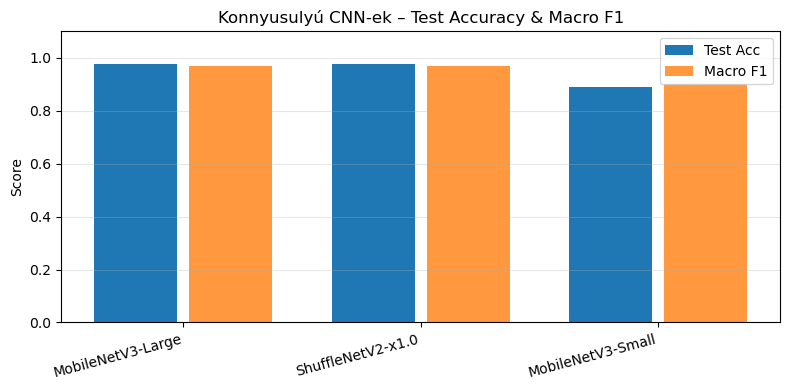

In [7]:
results_df = pd.DataFrame(ALL_RESULTS).sort_values("Test Acc", ascending=False)
print("\n=== 04b Leaderboard ===")
print(results_df.to_string(index=False))
results_df.to_csv(OUTPUT_DIR / "mobile_cnn_results.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(results_df))
ax.bar([i-0.2 for i in x], results_df["Test Acc"], width=0.35, label="Test Acc")
ax.bar([i+0.2 for i in x], results_df["Macro F1"],  width=0.35, label="Macro F1", alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(results_df["Model"], rotation=15, ha="right")
ax.set_ylim(0, 1.1); ax.set_ylabel("Score")
ax.set_title("Konnyusulyú CNN-ek – Test Accuracy & Macro F1")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "mobile_leaderboard.png", dpi=120, bbox_inches="tight")
plt.show()


## 8. Összefoglaló és következő lépések

### Eredmények rögzítve
- 3 könnyű CNN modell tanítva (MobileNetV3-Small/Large, ShuffleNetV2)
- Checkpointok mentve: `checkpoints/mobilenet_*.pth`, `shufflenet_*.pth`
- Eredmény CSV: `output/04b_mobile_cnn/mobile_cnn_results.csv`

### Várható teljesítmény (irodalom alapján)
- MobileNetV3-Large általában felülmúlja a Small verziót ~2–4%-kal
- ShuffleNetV2 hasonló tartományban mozog, mint MobileNetV3-Small

### Következő lépések – `04c_efficientnet.ipynb`
EfficientNet-B0 kétfázisú fine-tuning – ez az átnevezett korábbi `04_model.ipynb`.

| Notebook | Modell | Státusz |
|----------|--------|---------|
| 04a | SVM, RF, XGBoost (HOG + CNN features) | kész |
| 04b | MobileNetV3, ShuffleNetV2 | kész |
| **04c** | **EfficientNet-B0** | **következő** |
| 04d | ResNet-50, EfficientNet-B3 | tervezett |
| 04e | ViT-B/16 | tervezett |
